# 3D Data Visualization in Python (Matplotlib) — using real built-in datasets

This notebook walks through the main types of **3D plots** available in Matplotlib
(`mpl_toolkits.mplot3d`), but instead of made-up numbers, every plot uses a real,
**built-in dataset** from `scikit-learn` or `seaborn` (no files to download by hand,
no manual data entry).

For each plot type you'll get:
- A short explanation of **what the plot does**
- **Why that dataset** is a good fit for that particular plot
- Simple, commented code you can reuse later

**Datasets used:**
| Dataset | Source | Used for |
|---|---|---|
| Iris | `sklearn.datasets.load_iris` | 3D Scatter Plot |
| Digits | `sklearn.datasets.load_digits` | 3D Scatter Plot (with PCA) |
| Flights | `seaborn.load_dataset('flights')` | 3D Line Plot, Surface Plot, Wireframe Plot |
| Diabetes | `sklearn.datasets.load_diabetes` | 3D Filled Contour / Regression Surface |
| Wine | `sklearn.datasets.load_wine` | Surface Triangulation Plot |
| (pure math, no dataset) | — | Möbius Strip Plot (bonus, shows matplotlib's 3D geometry power) |

Run the cells top to bottom.


In [1]:
# Core imports used throughout the notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D   # enables the 3D projection
from matplotlib.tri import Triangulation

# Datasets
from sklearn.datasets import load_iris, load_digits, load_diabetes, load_wine
import seaborn as sns

# Make plots reasonably sized and readable
plt.rcParams['figure.figsize'] = (7, 6)


## 1. 3D Scatter Plot — Iris dataset

**What it shows:** each point is plotted at its own `(x, y, z)` position. It's the
go-to plot when you want to see whether groups of data form separate **clusters**.

**Why Iris fits this plot:** Iris has 3 flower species described by 4 numeric
measurements (sepal length/width, petal length/width). Picking any 3 of those
measurements as x, y, z and coloring by species is a classic way to *see* whether
the species are separable just from these physical measurements — exactly what a
3D scatter plot is good at.


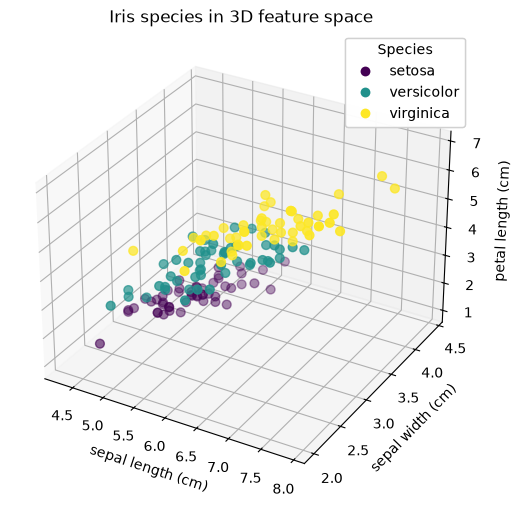

In [2]:
iris = load_iris()
X = iris.data          # shape (150, 4) -> sepal length, sepal width, petal length, petal width
y = iris.target        # species label: 0, 1, 2
species_names = iris.target_names

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Use 3 of the 4 features as the 3 axes
sc = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=y, cmap='viridis', s=40)

ax.set_xlabel(iris.feature_names[0])
ax.set_ylabel(iris.feature_names[1])
ax.set_zlabel(iris.feature_names[2])
ax.set_title('Iris species in 3D feature space')

# Add a legend mapping colors to species names
legend_labels = ax.legend(sc.legend_elements()[0], species_names, title="Species")
ax.add_artist(legend_labels)

plt.show()


## 2. 3D Scatter Plot (with PCA) — Digits dataset

**What it shows:** the same idea as above (points in 3D, colored by class), but
now applied after **dimensionality reduction**.

**Why Digits fits this plot:** the Digits dataset has images of handwritten digits
(0–9), each represented by **64 pixel values** — far too many dimensions to plot
directly. We use **PCA** to compress those 64 numbers down to just 3, and plot
the result. This is one of the most common real-world uses of a 3D scatter plot:
checking, by eye, whether a high-dimensional dataset has separable structure once
compressed to 3 dimensions.


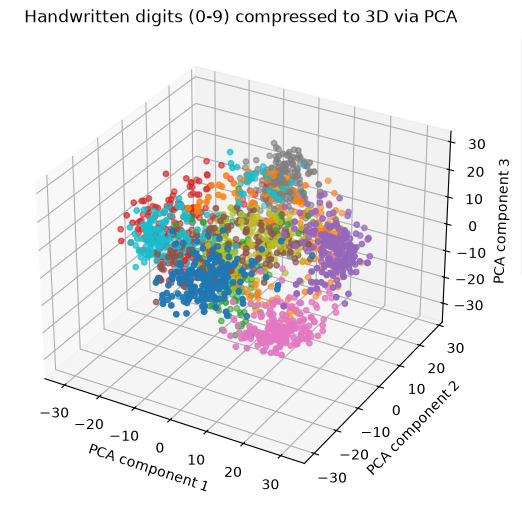

In [3]:
from sklearn.decomposition import PCA

digits = load_digits()
X = digits.data       # shape (1797, 64) -> 8x8 pixel images flattened
y = digits.target     # digit label: 0-9

# Reduce 64 dimensions down to 3 so we can actually plot them
pca = PCA(n_components=3)
X_3d = pca.fit_transform(X)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(X_3d[:, 0], X_3d[:, 1], X_3d[:, 2], c=y, cmap='tab10', s=15)

ax.set_xlabel('PCA component 1')
ax.set_ylabel('PCA component 2')
ax.set_zlabel('PCA component 3')
ax.set_title('Handwritten digits (0-9) compressed to 3D via PCA')

legend1 = ax.legend(*sc.legend_elements(), title="Digit", loc='upper right', bbox_to_anchor=(1.25, 1))
ax.add_artist(legend1)

plt.show()


## Loading the "flights" dataset (used by the next 3 plots)

The **flights** dataset (built into seaborn) records the number of airline
**passengers per month, per year, from 1949–1960**. It's a perfect fit for
line/surface/wireframe plots because it is naturally organised on a
**grid of (year, month) → passengers**, which is exactly the shape those
plot types expect.


In [4]:
flights = sns.load_dataset('flights')
print(flights.head())
print(flights.shape)

# Pivot into a grid: rows = year, columns = month, values = passenger count
flights_grid = flights.pivot(index='year', columns='month', values='passengers')

# Keep months in calendar order (Jan -> Dec) instead of alphabetical
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
flights_grid = flights_grid[month_order]

flights_grid.head()


   year month  passengers
0  1949   Jan         112
1  1949   Feb         118
2  1949   Mar         132
3  1949   Apr         129
4  1949   May         121
(144, 3)


month,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
year,,,,,,,,,,,,
1949,112,118,132,129,121,135,148,148,136,119,104,118
1950,115,126,141,135,125,149,170,170,158,133,114,140
1951,145,150,178,163,172,178,199,199,184,162,146,166
1952,171,180,193,181,183,218,230,242,209,191,172,194
1953,196,196,236,235,229,243,264,272,237,211,180,201


## 3. 3D Line Plot — Flights dataset

**What it shows:** a single continuous path traced through 3D space, in order.
Good for visualizing how something **evolves over time**.

**Why Flights fits this plot:** the data has a natural time order (month by
month, year by year). Plotting `x = month number`, `y = year`, `z = passenger
count`, and connecting the points **in chronological order**, draws a path that
climbs and drifts as air travel grew through the 1950s — a genuine trajectory,
not an arbitrary line.


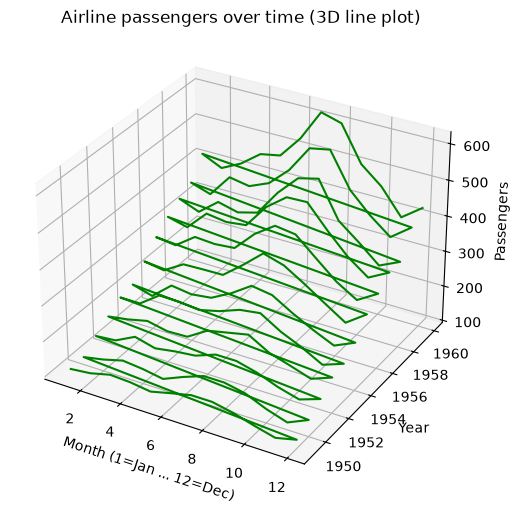

In [5]:
flights_sorted = flights.copy()
flights_sorted['month_num'] = flights_sorted['month'].apply(lambda m: month_order.index(m) + 1)
flights_sorted = flights_sorted.sort_values(['year', 'month_num'])

x = flights_sorted['month_num'].values
y = flights_sorted['year'].values
z = flights_sorted['passengers'].values

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot3D(x, y, z, color='green')

ax.set_xlabel('Month (1=Jan ... 12=Dec)')
ax.set_ylabel('Year')
ax.set_zlabel('Passengers')
ax.set_title('Airline passengers over time (3D line plot)')

plt.show()


## 4. Surface Plot — Flights dataset

**What it shows:** a continuous surface stretched over a grid of `(x, y)` values,
with height given by `z`. Great for seeing the overall **shape/topography** of
data that depends on two variables at once.

**Why Flights fits this plot:** the pivoted flights table is already a grid of
`(year, month) -> passengers`, with no extra work needed. The surface makes both
patterns visible at a glance: the **yearly growth trend** (surface rising as
years increase) and the **seasonal summer peaks** (ridges around June–August
each year).


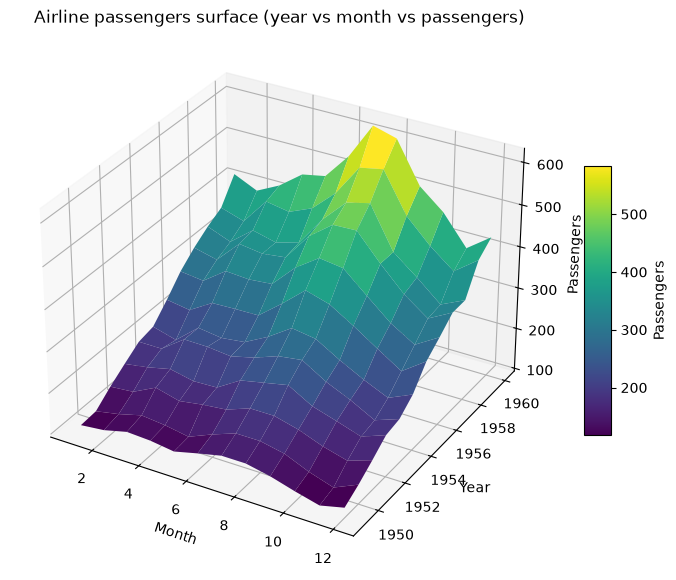

In [6]:
years = flights_grid.index.values                 # 1949 ... 1960
months = np.arange(1, 13)                          # 1 ... 12

X, Y = np.meshgrid(months, years)                   # build the (month, year) grid
Z = flights_grid.values                             # passenger counts on that grid

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')

ax.set_xlabel('Month')
ax.set_ylabel('Year')
ax.set_zlabel('Passengers')
ax.set_title('Airline passengers surface (year vs month vs passengers)')

fig.colorbar(surf, shrink=0.5, aspect=10, label='Passengers')
plt.show()


## 5. Wireframe Plot — Flights dataset

**What it shows:** the same grid-shaped surface as above, but drawn as just the
**mesh lines** with no color fill. Useful when you want to see the underlying
structure/shape clearly, without a colored surface hiding lines behind it.

**Why Flights fits this plot:** it's the same year/month/passenger grid used for
the surface plot — showing it as a wireframe makes the **rising trend and
seasonal bumps** easy to trace line by line, especially useful if you also want
to overlay something else on top later.


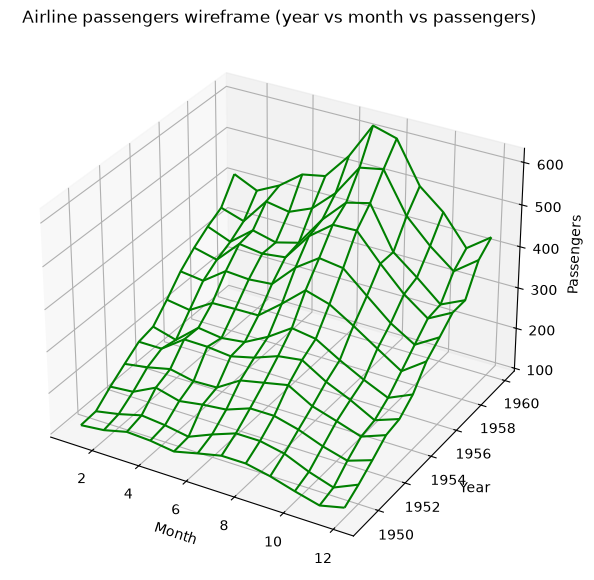

In [7]:
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot_wireframe(X, Y, Z, color='green')

ax.set_xlabel('Month')
ax.set_ylabel('Year')
ax.set_zlabel('Passengers')
ax.set_title('Airline passengers wireframe (year vs month vs passengers)')

plt.show()


## 6. 3D Filled Surface / Contour Plot — Diabetes dataset (regression surface)

**What it shows:** a smooth surface (with contour-like shading) built from a
**model's predictions** across a grid, with the real data points scattered on
top for comparison. This is a common way to visualize how a regression model
depends on two input features at once.

**Why Diabetes fits this plot:** the Diabetes dataset has real patients with
measured features (here: **BMI** and **average blood pressure**) and a numeric
target (disease progression after 1 year). There's no natural grid, so we fit a
simple model, **predict over an evenly spaced grid** of BMI/BP values, and plot
that prediction as a surface — a realistic case for 3D contour-style plots:
visualizing a fitted relationship, not just raw data.


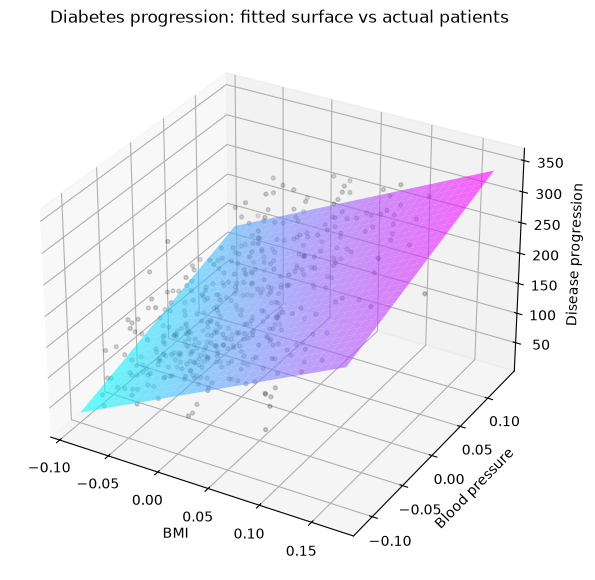

In [8]:
from sklearn.linear_model import LinearRegression

diabetes = load_diabetes()
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df['target'] = diabetes.target

# Use two features: bmi and bp (average blood pressure)
X_feat = df[['bmi', 'bp']].values
z_target = df['target'].values

model = LinearRegression().fit(X_feat, z_target)

# Build a grid across the range of bmi and bp, then predict on it
bmi_range = np.linspace(df['bmi'].min(), df['bmi'].max(), 30)
bp_range = np.linspace(df['bp'].min(), df['bp'].max(), 30)
BMI, BP = np.meshgrid(bmi_range, bp_range)
grid_points = np.column_stack([BMI.ravel(), BP.ravel()])
Z_pred = model.predict(grid_points).reshape(BMI.shape)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

# Predicted surface
ax.plot_surface(BMI, BP, Z_pred, cmap='cool', alpha=0.6)

# Real patient data points on top of the fitted surface
ax.scatter(df['bmi'], df['bp'], df['target'], color='black', s=8, alpha=0.5, label='Actual patients')

ax.set_xlabel('BMI')
ax.set_ylabel('Blood pressure')
ax.set_zlabel('Disease progression')
ax.set_title('Diabetes progression: fitted surface vs actual patients')

plt.show()


## 7. Surface Triangulation Plot — Wine dataset

**What it shows:** a surface built from **triangular patches** connecting
scattered `(x, y, z)` points, instead of a regular grid. It's the right tool
when your data points are **not** arranged on a neat grid — which is most real
data.

**Why Wine fits this plot:** the Wine dataset has chemical measurements of wine
samples (alcohol content, malic acid, color intensity, etc.). These values occur
at **irregular, scattered** combinations — no two wines have exactly matching
alcohol/malic-acid pairs on a grid — so `plot_surface()` (which needs a grid)
doesn't apply directly. `plot_trisurf()` handles this by triangulating the
scattered points itself.


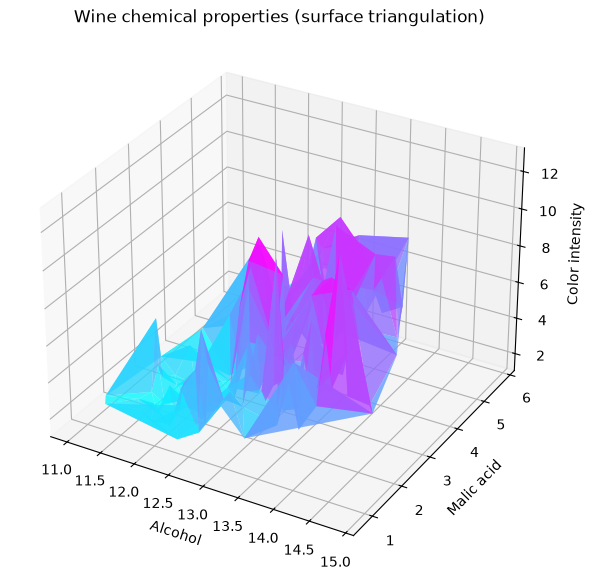

In [9]:
wine = load_wine()
df_wine = pd.DataFrame(wine.data, columns=wine.feature_names)

x = df_wine['alcohol'].values
y = df_wine['malic_acid'].values
z = df_wine['color_intensity'].values

tri = Triangulation(x, y)   # build triangles connecting the scattered (x, y) points

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot_trisurf(tri, z, cmap='cool', edgecolor='none', alpha=0.8)

ax.set_xlabel('Alcohol')
ax.set_ylabel('Malic acid')
ax.set_zlabel('Color intensity')
ax.set_title('Wine chemical properties (surface triangulation)')

plt.show()


## 8. Bonus: Möbius Strip Plot (pure geometry, no dataset)

**What it shows:** a classic one-sided, twisted surface from topology, built
entirely from a parametric equation.

**Why there's no dataset here:** this one isn't about visualizing measured data
at all — it's included because it's part of the standard matplotlib 3D toolkit
demo set and is a nice way to see how flexible `plot_surface()` is for **any**
mathematically defined shape, not just data-driven ones. Feel free to skip this
cell if you only care about data visualizations.


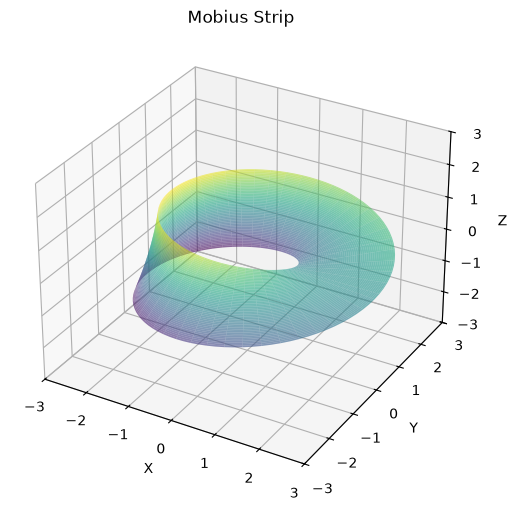

In [10]:
R = 2                                     # radius of the strip's center circle
u = np.linspace(0, 2 * np.pi, 100)        # angle around the strip
v = np.linspace(-1, 1, 100)               # position across the width of the strip
u, v = np.meshgrid(u, v)

x = (R + v * np.cos(u / 2)) * np.cos(u)
y = (R + v * np.cos(u / 2)) * np.sin(u)
z = v * np.sin(u / 2)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(x, y, z, alpha=0.6, cmap='viridis')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Mobius Strip')

ax.set_xlim([-3, 3])
ax.set_ylim([-3, 3])
ax.set_zlim([-3, 3])

plt.show()


## Recap

| Plot type | Best for | Dataset used here |
|---|---|---|
| 3D Scatter | Seeing clusters/groups | Iris |
| 3D Scatter + PCA | Seeing structure in high-dimensional data | Digits |
| 3D Line | Tracing an ordered path / trend over time | Flights |
| Surface | Full continuous shape over a grid of 2 variables | Flights |
| Wireframe | Same as surface, but structure without color fill | Flights |
| Filled surface / contour-style | Visualizing a fitted model's predictions | Diabetes |
| Surface Triangulation | Irregular / non-grid scattered data | Wine |
| Möbius Strip | Pure geometry / topology demo | — |

You can reuse any of these cells as a template: swap in your own `x, y, z` (or your
own dataframe columns) and keep the plotting code as-is.


---
# Part 2: Visualizing datasets with MORE than 3 dimensions

A plot only has 2 or 3 spatial axes, so once a dataset has 4+ numeric features
(like Wine with 13, or Digits with 64), you can't plot every dimension directly.
Below are the standard ways around that, each demonstrated on a real dataset.


## A. Pair Plot (scatterplot matrix) — Wine dataset

**What it shows:** every pair of features plotted against each other as small
2D scatter plots, arranged in a grid, with histograms on the diagonal. Nothing
is reduced or compressed — you're just looking at the data two dimensions at a
time.

**Why Wine fits this:** it has 13 chemical features, a manageable number to lay
out as a grid. This is usually the *first* thing to try on a new dataset, since
it needs no math beyond plotting.


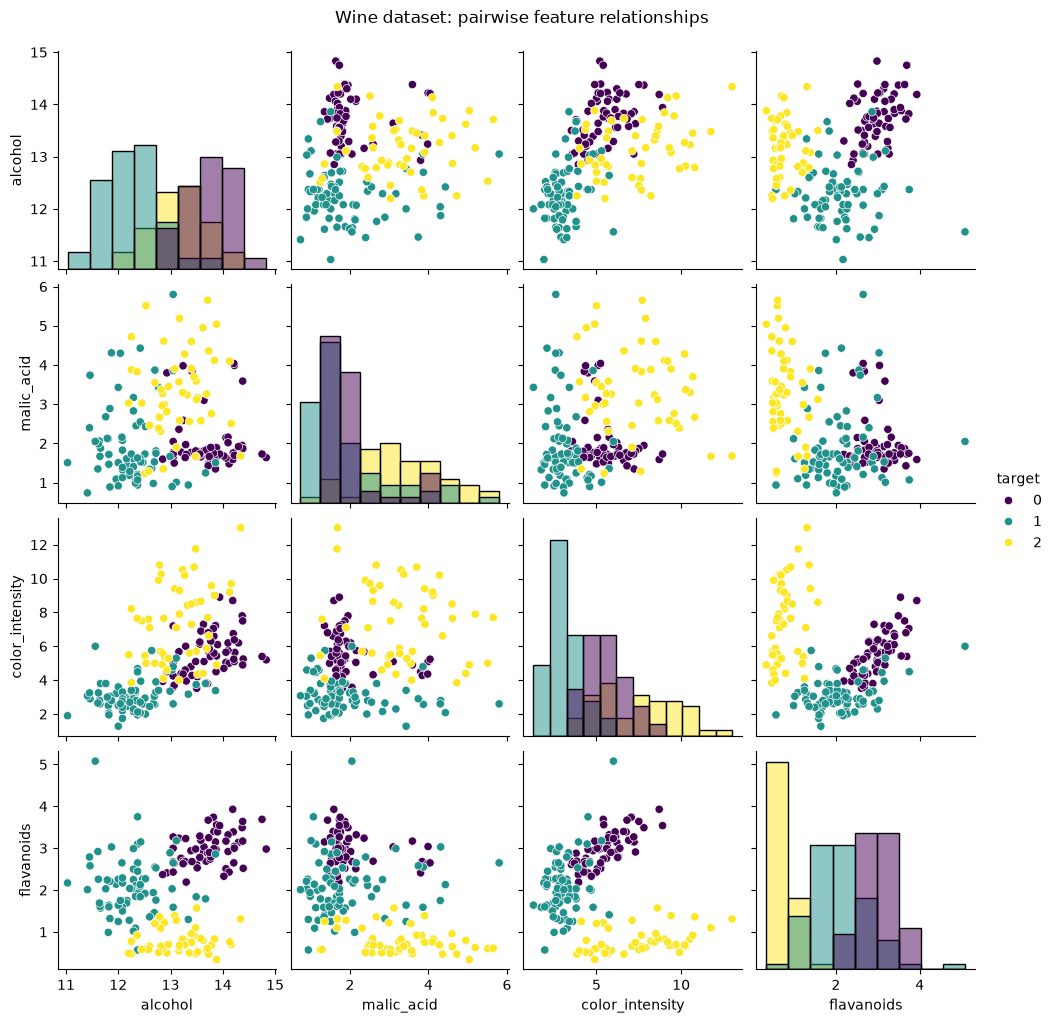

In [11]:
df_wine_full = pd.DataFrame(wine.data, columns=wine.feature_names)
df_wine_full['target'] = wine.target

# Just look at a handful of features to keep the grid readable
cols = ['alcohol', 'malic_acid', 'color_intensity', 'flavanoids', 'target']

sns.pairplot(df_wine_full[cols], hue='target', palette='viridis', diag_kind='hist')
plt.suptitle('Wine dataset: pairwise feature relationships', y=1.02)
plt.show()


## B. Parallel Coordinates — Wine dataset

**What it shows:** one vertical axis per feature (all features, side by side),
and each data point is drawn as a **line** connecting its value on every axis.
Unlike a pair plot, this shows *all* dimensions in a single picture — you just
lose the precise geometric relationships between any two specific features.

**Why Wine fits this:** with 13 numeric features and 3 known classes, it's easy
to see which features separate the wine classes cleanly (axes where the colored
lines bunch into separate bands) versus which don't add much information.


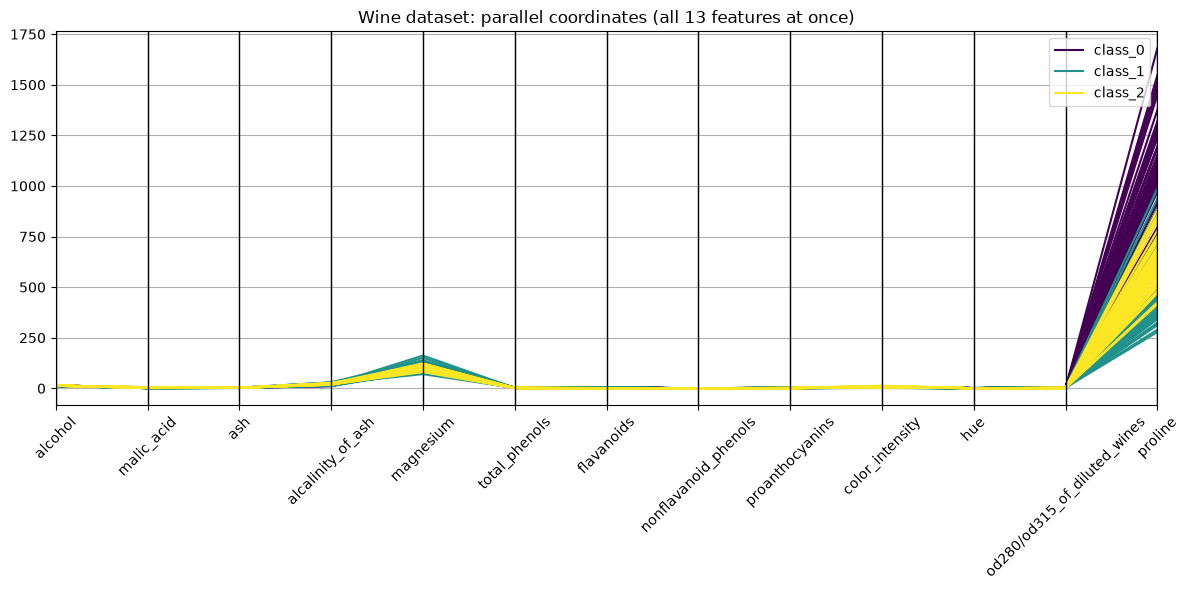

In [12]:
from pandas.plotting import parallel_coordinates

df_pc = df_wine_full.copy()
df_pc['target'] = df_pc['target'].map({0: 'class_0', 1: 'class_1', 2: 'class_2'})

plt.figure(figsize=(12, 6))
parallel_coordinates(df_pc, 'target', color=('#440154', '#21918c', '#fde725'))
plt.xticks(rotation=45)
plt.title('Wine dataset: parallel coordinates (all 13 features at once)')
plt.tight_layout()
plt.show()


## C. t-SNE (non-linear reduction) — Digits dataset

**What it shows:** like PCA, this compresses many dimensions down to 2 (or 3)
so you can plot them — but t-SNE is **non-linear**, so it's often much better
than PCA at revealing tight, separate clusters, at the cost of not preserving
real distances/scales (only relative grouping is meaningful).

**Why Digits fits this:** 64 pixel-value dimensions are too non-linear/complex
for PCA alone to cleanly separate. t-SNE typically shows the 10 digit classes
as much tighter, more distinct blobs than the PCA version you saw earlier.


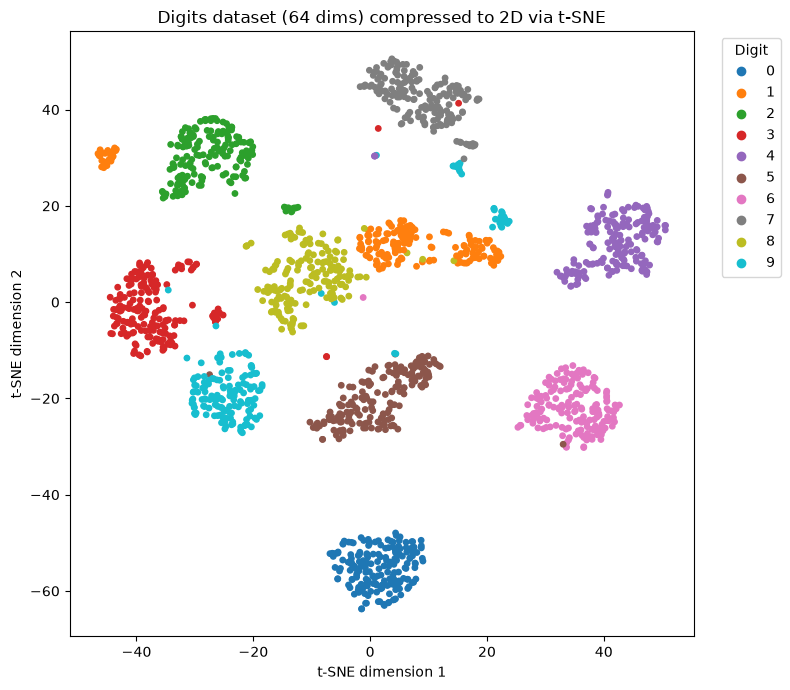

In [13]:
from sklearn.manifold import TSNE

# perplexity controls how local vs global the clustering behavior is
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(digits.data)

plt.figure(figsize=(8, 7))
sc = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=digits.target, cmap='tab10', s=15)
plt.legend(*sc.legend_elements(), title='Digit', bbox_to_anchor=(1.15, 1))
plt.title('Digits dataset (64 dims) compressed to 2D via t-SNE')
plt.xlabel('t-SNE dimension 1')
plt.ylabel('t-SNE dimension 2')
plt.tight_layout()
plt.show()


## D. Correlation Heatmap — Wine dataset

**What it shows:** not the raw data points, but how every feature relates to
every other feature (correlation from -1 to 1), as a color grid. It's a quick
way to see redundant features (strong correlation) or independent ones (near
zero) across *all* dimensions simultaneously.

**Why Wine fits this:** with 13 features, a heatmap is often faster to scan
than a full pair plot for spotting which features move together.


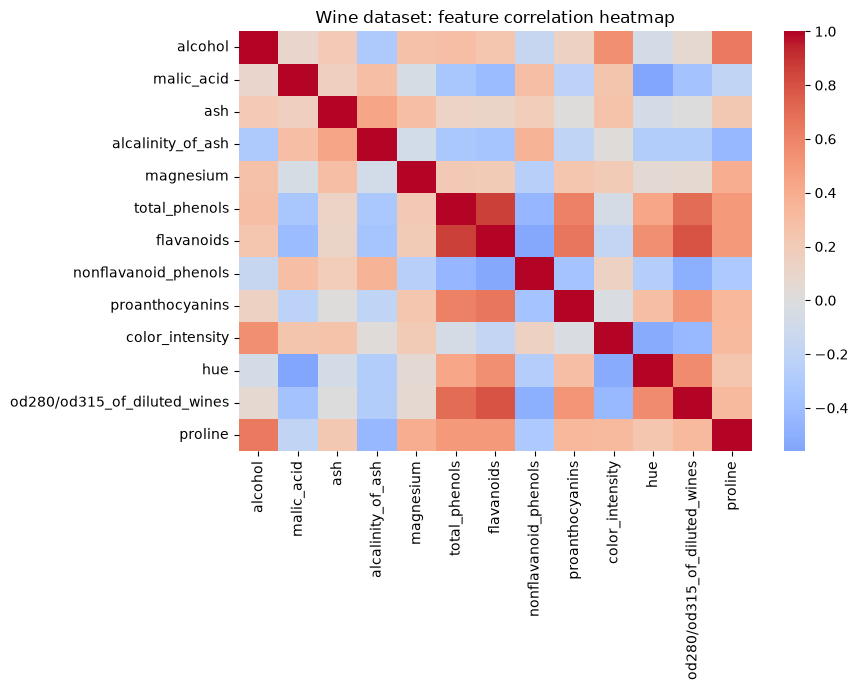

In [14]:
plt.figure(figsize=(9, 7))
corr = df_wine_full.drop(columns='target').corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Wine dataset: feature correlation heatmap')
plt.tight_layout()
plt.show()


## Which one should you use?

| Technique | Good when | Watch out for |
|---|---|---|
| PCA (2D/3D) | Quick, linear, fast | Misses non-linear structure |
| t-SNE / UMAP | Best visual cluster separation | Distances aren't meaningful, slower, randomness between runs |
| Pair plot | Small/medium number of features (<~10) | Gets cluttered fast with many features |
| Parallel coordinates | Want to see all features in one image | Can get messy with too many rows or features |
| Correlation heatmap | Want to see redundancy/relationships, not raw data | Doesn't show individual data points at all |
